Training Images Shape: (60000, 28, 28)
Testing Images Shape: (10000, 28, 28)
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 18s 33ms/step - accuracy: 0.9321 - loss: 0.2333
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - accuracy: 0.9759 - loss: 0.0796
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.9826 - loss: 0.0565
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.9869 - loss: 0.0422
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - accuracy: 0.9893 - loss: 0.0343

Test Loss: 0.03883899375796318
Test Accuracy: 0.987500011920929
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

Confusion Matrix:
[[ 975    0    3    0    0    0    1    1    0    0]
 [   0 1130    1    0    0    0    2    2    0    0]
 [   1    4 1018    0    2    0    0    6    1    0]
 [   0    0    1  999    0    4    0    3    2    1]
 [   0    0    1    0  977    0    0    1    0    3]
 [   1    0    0    4    0  885    2    0    0    0]
 [   8    3    1    0    1    4  940    0    

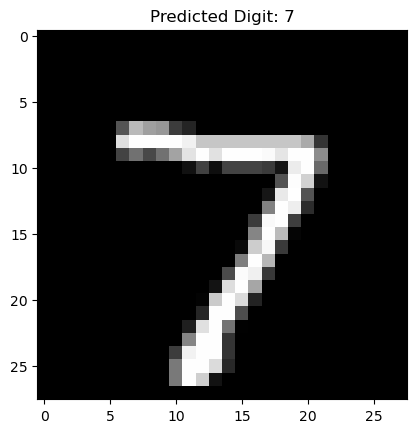

In [4]:
# =========================================================
# Deep Learning Lab 2
# CNN Multiclass Classifier using MNIST Dataset
# =========================================================

# Import required libraries
import numpy as np
import matplotlib.pyplot as plt

# Import TensorFlow and Keras modules
from tensorflow import keras
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

# Import confusion matrix
from sklearn.metrics import confusion_matrix

# =========================================================
# Load MNIST Dataset
# =========================================================

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# =========================================================
# Display dataset shapes
# =========================================================

print("Training Images Shape:", x_train.shape)
print("Testing Images Shape:", x_test.shape)

# =========================================================
# Reshape dataset for CNN
# =========================================================

x_train = x_train.reshape(60000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)

# =========================================================
# Convert datatype to float
# =========================================================

x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

# =========================================================
# Normalize pixel values (0 to 255 → 0 to 1)
# =========================================================

x_train = x_train / 255
x_test = x_test / 255

# =========================================================
# Convert output labels into categorical format
# =========================================================

y_train = keras.utils.to_categorical(y_train, 10)
y_test = keras.utils.to_categorical(y_test, 10)

# =========================================================
# Build CNN Model
# =========================================================

model = Sequential()

# First Convolution Layer
model.add(Conv2D(32, kernel_size=(3,3),
                 activation='relu',
                 input_shape=(28,28,1)))

# Max Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Dropout Layer
model.add(Dropout(0.25))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Output Layer
model.add(Dense(10, activation='softmax'))

# =========================================================
# Compile Model
# =========================================================

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# =========================================================
# Train Model
# =========================================================

model.fit(x_train,
          y_train,
          epochs=5,
          batch_size=128,
          verbose=1)

# =========================================================
# Evaluate Model
# =========================================================

score = model.evaluate(x_test, y_test, verbose=0)

print("\nTest Loss:", score[0])
print("Test Accuracy:", score[1])

# =========================================================
# Predict Classes
# =========================================================

y_pred = model.predict(x_test)

# Convert predictions into class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Convert one-hot encoded test labels back to single labels
y_true = np.argmax(y_test, axis=1)

# =========================================================
# Generate Confusion Matrix
# =========================================================

cm = confusion_matrix(y_true, y_pred_classes)

print("\nConfusion Matrix:")
print(cm)

# =========================================================
# Display Sample Image Prediction
# =========================================================

plt.imshow(x_test[0].reshape(28,28), cmap='gray')

plt.title("Predicted Digit: {}".format(y_pred_classes[0]))

plt.show()